# Phase 3: Feature Engineering & Baseline Model

Project : MBTI Personality Type Prediction from Text
Dataset : Cleaned output from Phase 2 (mbti_cleaned.csv)

Strategy -- 4 Binary Classifiers (not 1 x 16-class):
---
Predicting all 16 MBTI types at once yields poor accuracy because:
(a) 16-class imbalance is extreme (47x ratio)
(b) The 4 MBTI dimensions are conceptually independent axes

Instead, we decompose the problem into 4 BINARY classification tasks:
Axis 0:  E vs I  (Extraversion / Introversion)
Axis 1:  S vs N  (Sensing / iNtuition)
Axis 2:  T vs F  (Thinking / Feeling)
Axis 3:  J vs P  (Judging / Perceiving)

Each axis gets its own TF-IDF features and its own Logistic Regression
model.  This is the standard, well-proven approach for MBTI prediction.

Pipeline:
1. Load cleaned data
2. Create 4 binary target columns
3. TF-IDF vectorization (top 5000 features)
4. Stratified 80/20 train/test split
5. Train Logistic Regression per axis
6. Evaluate with accuracy, precision, recall, F1-score


In [1]:
%matplotlib inline

In [2]:
# -- Imports ------------------------------------------------------------------
import os
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Suppress convergence warnings for cleaner output (we'll increase
# max_iter if needed, but LR usually converges fine at 1000 iters).
warnings.filterwarnings("ignore", category=UserWarning)

# -- Configuration ------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

DATA_PATH = os.path.join(os.getcwd(), "mbti_cleaned.csv")

# The 4 MBTI dimensions we'll build binary classifiers for.
# Each tuple is (axis_name, position_in_type_string, label_0, label_1).
# We predict the SECOND letter as the positive class (1), FIRST as (0).
MBTI_AXES = [
    ("E_I", 0, "E", "I"),   # Extraversion(0) vs Introversion(1)
    ("S_N", 1, "S", "N"),   # Sensing(0)      vs iNtuition(1)
    ("T_F", 2, "T", "F"),   # Thinking(0)     vs Feeling(1)
    ("J_P", 3, "J", "P"),   # Judging(0)      vs Perceiving(1)
]

# TF-IDF hyperparameters
MAX_FEATURES = 5000     # Keep top 5000 terms by TF-IDF score
MAX_DF = 0.95           # Ignore terms appearing in >95% of docs (too common)
MIN_DF = 2              # Ignore terms appearing in <2 docs (too rare)
NGRAM_RANGE = (1, 2)    # Unigrams + bigrams (captures phrases like "feel like")

# Logistic Regression hyperparameters
LR_MAX_ITER = 1000      # Sufficient for convergence on TF-IDF features
LR_C = 1.0              # Regularisation strength (inverse); default is fine
LR_SOLVER = "lbfgs"     # Good default for binary classification

## 1. LOAD AND PREPARE DATA


In [3]:
def load_and_prepare(path: str = DATA_PATH) -> pd.DataFrame:
    """
    Load the cleaned dataset and create 4 binary target columns.

    Each binary column encodes one MBTI dimension:
        E_I = 0 for Extraversion, 1 for Introversion
        S_N = 0 for Sensing,      1 for iNtuition
        T_F = 0 for Thinking,     1 for Feeling
        J_P = 0 for Judging,      1 for Perceiving

    Also drops any rows where clean_posts is null/empty (from Phase 2
    edge cases).
    """
    df = pd.read_csv(path)

    print("=" * 60)
    print("  PHASE 3: FEATURE ENGINEERING & BASELINE MODEL")
    print("=" * 60)
    print(f"  Loaded {len(df)} rows from {os.path.basename(path)}")

    # -- Handle edge cases from Phase 2 --------------------------------------
    # Drop rows where clean_posts is null or empty
    before = len(df)
    df = df.dropna(subset=["clean_posts"])
    df = df[df["clean_posts"].str.strip() != ""]
    df = df.reset_index(drop=True)
    dropped = before - len(df)
    if dropped > 0:
        print(f"  Dropped {dropped} empty/null rows -> {len(df)} remaining")

    # -- Create binary target columns ----------------------------------------
    for axis_name, pos, label_0, label_1 in MBTI_AXES:
        # Extract the character at position `pos` from the 4-letter type
        # and encode: label_0 -> 0,  label_1 -> 1
        df[axis_name] = (df["type"].str[pos] == label_1).astype(int)

    # Print the class balance for each axis
    print("\n  Binary target distributions:")
    print("  " + "-" * 50)
    for axis_name, pos, label_0, label_1 in MBTI_AXES:
        counts = df[axis_name].value_counts()
        n0 = counts.get(0, 0)
        n1 = counts.get(1, 0)
        pct1 = n1 / len(df) * 100
        print(f"    {axis_name}: {label_0}={n0}  {label_1}={n1}  "
              f"({label_1} = {pct1:.1f}%)")
    print("  " + "-" * 50)

    return df

## 2. TF-IDF VECTORIZATION


In [4]:
def build_tfidf(X_train_text, X_test_text):
    """
    Fit a TF-IDF vectorizer on training text and transform both sets.

    Returns the fitted vectorizer (for later inspection) and the
    sparse feature matrices.

    Key design choices:
        - max_features=5000: Keeps the model tractable while capturing
          the most discriminative terms.
        - ngram_range=(1,2): Bigrams like "feel like", "think about"
          carry personality signal that unigrams alone miss.
        - sublinear_tf=True: Applies log(1+tf) to dampen the effect of
          very frequent words within a single document.
        - max_df=0.95: Removes terms so common they appear in nearly
          every user's posts (useless for discrimination).
        - min_df=2: Removes extremely rare terms (likely typos or
          unique proper nouns).
    """
    print("\n  TF-IDF Vectorization:")

    tfidf = TfidfVectorizer(
        max_features=MAX_FEATURES,
        ngram_range=NGRAM_RANGE,
        max_df=MAX_DF,
        min_df=MIN_DF,
        sublinear_tf=True,         # log-normalised term frequencies
        strip_accents="unicode",
    )

    start = time.time()
    X_train_tfidf = tfidf.fit_transform(X_train_text)
    X_test_tfidf  = tfidf.transform(X_test_text)
    elapsed = time.time() - start

    print(f"    Vocabulary size  : {len(tfidf.vocabulary_):,}")
    print(f"    Train matrix     : {X_train_tfidf.shape}")
    print(f"    Test  matrix     : {X_test_tfidf.shape}")
    print(f"    Sparsity         : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")
    print(f"    Vectorization in : {elapsed:.2f}s")

    return tfidf, X_train_tfidf, X_test_tfidf

## 3. TRAIN AND EVALUATE LOGISTIC REGRESSION


In [5]:
def train_and_evaluate(X_train, X_test, y_train, y_test,
                       axis_name, label_0, label_1):
    """
    Train a Logistic Regression classifier for one MBTI axis and
    print the evaluation metrics.

    Why Logistic Regression as baseline?
        - Fast to train on sparse TF-IDF features
        - Interpretable (we can inspect feature coefficients)
        - Strong baseline that often outperforms more complex models
          on text classification with TF-IDF
        - Built-in L2 regularisation prevents overfitting

    We use class_weight='balanced' to automatically upweight the
    minority class in proportion to its frequency, addressing the
    imbalance without needing SMOTE or oversampling.
    """
    print(f"\n  {'=' * 56}")
    print(f"  AXIS: {axis_name}  ({label_0} vs {label_1})")
    print(f"  {'=' * 56}")

    # -- Train ----------------------------------------------------------------
    model = LogisticRegression(
        max_iter=LR_MAX_ITER,
        C=LR_C,
        solver=LR_SOLVER,
        class_weight="balanced",  # Critical for imbalanced datasets
        random_state=42,
        n_jobs=-1,                # Use all CPU cores
    )

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # -- Predict --------------------------------------------------------------
    y_pred = model.predict(X_test)

    # -- Metrics --------------------------------------------------------------
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")

    print(f"\n  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1 (weighted)  : {f1:.4f}")
    print(f"  Training time  : {train_time:.2f}s")

    # Full classification report
    report = classification_report(
        y_test, y_pred,
        target_names=[label_0, label_1],
        digits=4,
    )
    print(f"\n  Classification Report:")
    # Indent the report for cleaner formatting
    for line in report.split("\n"):
        print(f"    {line}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"    Predicted ->  {label_0:>6s}  {label_1:>6s}")
    print(f"    Actual {label_0}   : {cm[0][0]:>6d}  {cm[0][1]:>6d}")
    print(f"    Actual {label_1}   : {cm[1][0]:>6d}  {cm[1][1]:>6d}")

    return model, acc, f1, y_pred

## 4. VISUALIZE RESULTS


In [6]:
def plot_results(results: dict, y_tests: dict, y_preds: dict) -> None:
    """
    Create a summary visualization with:
        - Bar chart of accuracy per axis
        - Confusion matrix heatmaps for each axis
    """
    fig, axes = plt.subplots(1, 5, figsize=(26, 5))

    # -- Plot 1: Accuracy comparison bar chart --------------------------------
    ax0 = axes[0]
    axis_names = list(results.keys())
    accuracies = [results[a]["accuracy"] for a in axis_names]
    f1_scores  = [results[a]["f1"] for a in axis_names]

    x = np.arange(len(axis_names))
    width = 0.35

    bars1 = ax0.bar(x - width/2, accuracies, width, label="Accuracy",
                    color="#3498DB", edgecolor="white", alpha=0.85)
    bars2 = ax0.bar(x + width/2, f1_scores, width, label="F1 (weighted)",
                    color="#E74C3C", edgecolor="white", alpha=0.85)

    ax0.set_xticks(x)
    ax0.set_xticklabels(axis_names, fontweight="bold")
    ax0.set_ylabel("Score")
    ax0.set_title("Baseline Model Performance", fontweight="bold")
    ax0.set_ylim(0, 1.0)
    ax0.legend(fontsize=9)

    # Annotate bars
    for bar in bars1:
        ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", fontsize=8, fontweight="bold")
    for bar in bars2:
        ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", fontsize=8, fontweight="bold")

    # -- Plots 2-5: Confusion matrices ----------------------------------------
    for i, (axis_name, _, label_0, label_1) in enumerate(MBTI_AXES):
        ax = axes[i + 1]
        cm = confusion_matrix(y_tests[axis_name], y_preds[axis_name])

        # Normalise for percentage display
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=[label_0, label_1],
            yticklabels=[label_0, label_1],
            cbar=False,
        )
        ax.set_title(f"{axis_name}\nAcc: {results[axis_name]['accuracy']:.3f}",
                     fontweight="bold", fontsize=11)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        # Add percentage annotations below the count
        for row in range(2):
            for col in range(2):
                ax.text(col + 0.5, row + 0.75,
                        f"({cm_pct[row][col]:.1f}%)",
                        ha="center", va="center", fontsize=8, color="gray")

    plt.suptitle("Logistic Regression Baseline -- 4 Binary MBTI Classifiers",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("phase3_baseline_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n  Chart saved: phase3_baseline_results.png")

## 5. TOP FEATURES ANALYSIS


In [7]:
def show_top_features(model, tfidf, axis_name, label_0, label_1, top_n=15):
    """
    Display the most discriminative words for each side of an MBTI axis.

    Logistic Regression coefficients directly tell us which words push
    the prediction toward class 0 vs class 1.  Positive coefficients
    indicate the word is associated with class 1 (the positive label).
    """
    feature_names = np.array(tfidf.get_feature_names_out())
    coefs = model.coef_[0]

    # Top features for class 1 (positive coefficients)
    top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
    # Top features for class 0 (most negative coefficients)
    top_neg_idx = np.argsort(coefs)[:top_n]

    print(f"\n  Top {top_n} words for {axis_name}:")
    print(f"  {'Words -> ' + label_1:>35s}  |  {label_0 + ' <- Words':<35s}")
    print(f"  {'-' * 35}  |  {'-' * 35}")
    for i in range(top_n):
        pos_word = feature_names[top_pos_idx[i]]
        pos_coef = coefs[top_pos_idx[i]]
        neg_word = feature_names[top_neg_idx[i]]
        neg_coef = coefs[top_neg_idx[i]]
        print(f"  {pos_word:>25s} ({pos_coef:+.4f})  |  "
              f"({neg_coef:+.4f}) {neg_word:<25s}")

## MAIN


In [8]:
def main():
    """Execute the full Phase 3 pipeline."""

    # Step 1: Load and prepare data
    df = load_and_prepare()

    # Step 2: Split data (80/20, stratified on the FULL 16-class type
    # to ensure each MBTI type appears proportionally in train and test)
    X_text = df["clean_posts"]
    y_full = df["type"]

    X_train_text, X_test_text, train_idx, test_idx = train_test_split(
        X_text,
        df.index,
        test_size=0.20,
        random_state=42,
        stratify=y_full,  # Stratify on the full type to preserve ALL ratios
    )

    print(f"\n  Train/Test Split:")
    print(f"    Train : {len(X_train_text)} ({len(X_train_text)/len(df)*100:.1f}%)")
    print(f"    Test  : {len(X_test_text)} ({len(X_test_text)/len(df)*100:.1f}%)")

    # Step 3: TF-IDF vectorization (fit on train, transform both)
    tfidf, X_train_tfidf, X_test_tfidf = build_tfidf(X_train_text, X_test_text)

    # Step 4: Train and evaluate 4 binary classifiers
    results = {}
    models = {}
    y_tests = {}
    y_preds = {}

    for axis_name, pos, label_0, label_1 in MBTI_AXES:
        # Extract the binary labels for this axis
        y_train = df.loc[train_idx, axis_name]
        y_test  = df.loc[test_idx, axis_name]

        model, acc, f1, y_pred = train_and_evaluate(
            X_train_tfidf, X_test_tfidf,
            y_train, y_test,
            axis_name, label_0, label_1,
        )

        results[axis_name] = {"accuracy": acc, "f1": f1}
        models[axis_name] = model
        y_tests[axis_name] = y_test
        y_preds[axis_name] = y_pred

    # Step 5: Summary
    print("\n" + "=" * 60)
    print("  BASELINE RESULTS SUMMARY")
    print("=" * 60)
    print(f"  {'Axis':<8s}  {'Accuracy':>10s}  {'F1 (wtd)':>10s}")
    print(f"  {'-'*8}  {'-'*10}  {'-'*10}")
    for axis_name in results:
        r = results[axis_name]
        print(f"  {axis_name:<8s}  {r['accuracy']:>10.4f}  {r['f1']:>10.4f}")
    avg_acc = np.mean([r["accuracy"] for r in results.values()])
    avg_f1  = np.mean([r["f1"] for r in results.values()])
    print(f"  {'-'*8}  {'-'*10}  {'-'*10}")
    print(f"  {'AVERAGE':<8s}  {avg_acc:>10.4f}  {avg_f1:>10.4f}")
    print("=" * 60)

    # Step 6: Top features per axis
    for (axis_name, pos, label_0, label_1), model in zip(MBTI_AXES, models.values()):
        show_top_features(model, tfidf, axis_name, label_0, label_1)

    # Step 7: Visualize results
    plot_results(results, y_tests, y_preds)

    print("\n[DONE]  Phase 3 complete -- baseline models trained and evaluated.")
    print("    Next -> Phase 4: Advanced Models & Hyperparameter Tuning\n")

    return df, models, tfidf, results

## Run Phase 3


  PHASE 3: FEATURE ENGINEERING & BASELINE MODEL
  Loaded 8675 rows from mbti_cleaned.csv
  Dropped 1 empty/null rows -> 8674 remaining

  Binary target distributions:
  --------------------------------------------------
    E_I: E=1999  I=6675  (I = 77.0%)
    S_N: S=1197  N=7477  (N = 86.2%)
    T_F: T=3981  F=4693  (F = 54.1%)
    J_P: J=3434  P=5240  (P = 60.4%)
  --------------------------------------------------

  Train/Test Split:
    Train : 6939 (80.0%)
    Test  : 1735 (20.0%)

  TF-IDF Vectorization:


    Vocabulary size  : 5,000
    Train matrix     : (6939, 5000)
    Test  matrix     : (1735, 5000)
    Sparsity         : 0.9287
    Vectorization in : 15.36s

  AXIS: E_I  (E vs I)

  Accuracy       : 0.7412  (74.12%)
  F1 (weighted)  : 0.7538
  Training time  : 0.08s

  Classification Report:
                  precision    recall  f1-score   support
    
               E     0.4552    0.6225    0.5259       400
               I     0.8729    0.7768    0.8220      1335
    
        accuracy                         0.7412      1735
       macro avg     0.6641    0.6996    0.6740      1735
    weighted avg     0.7766    0.7412    0.7538      1735
    

  Confusion Matrix:
    Predicted ->       E       I
    Actual E   :    249     151
    Actual I   :    298    1037

  AXIS: S_N  (S vs N)


C:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



  Accuracy       : 0.7937  (79.37%)
  F1 (weighted)  : 0.8096
  Training time  : 0.14s

  Classification Report:
                  precision    recall  f1-score   support
    
               S     0.3343    0.4958    0.3993       240
               N     0.9123    0.8415    0.8754      1495
    
        accuracy                         0.7937      1735
       macro avg     0.6233    0.6687    0.6374      1735
    weighted avg     0.8323    0.7937    0.8096      1735
    

  Confusion Matrix:
    Predicted ->       S       N
    Actual S   :    119     121
    Actual N   :    237    1258

  AXIS: T_F  (T vs F)

  Accuracy       : 0.7867  (78.67%)
  F1 (weighted)  : 0.7871
  Training time  : 0.08s

  Classification Report:
                  precision    recall  f1-score   support
    
               T     0.7527    0.7980    0.7747       797
               F     0.8191    0.7772    0.7976       938
    
        accuracy                         0.7867      1735
       macro avg     0.785

C:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



  Accuracy       : 0.6346  (63.46%)
  F1 (weighted)  : 0.6377
  Training time  : 0.14s

  Classification Report:
                  precision    recall  f1-score   support
    
               J     0.5333    0.6064    0.5675       686
               P     0.7173    0.6530    0.6836      1049
    
        accuracy                         0.6346      1735
       macro avg     0.6253    0.6297    0.6256      1735
    weighted avg     0.6445    0.6346    0.6377      1735
    

  Confusion Matrix:
    Predicted ->       J       P
    Actual J   :    416     270
    Actual P   :    364     685

  BASELINE RESULTS SUMMARY
  Axis        Accuracy    F1 (wtd)
  --------  ----------  ----------
  E_I           0.7412      0.7538
  S_N           0.7937      0.8096
  T_F           0.7867      0.7871
  J_P           0.6346      0.6377
  --------  ----------  ----------
  AVERAGE       0.7390      0.7470

  Top 15 words for E_I:
                           Words -> I  |  E <- Words                    

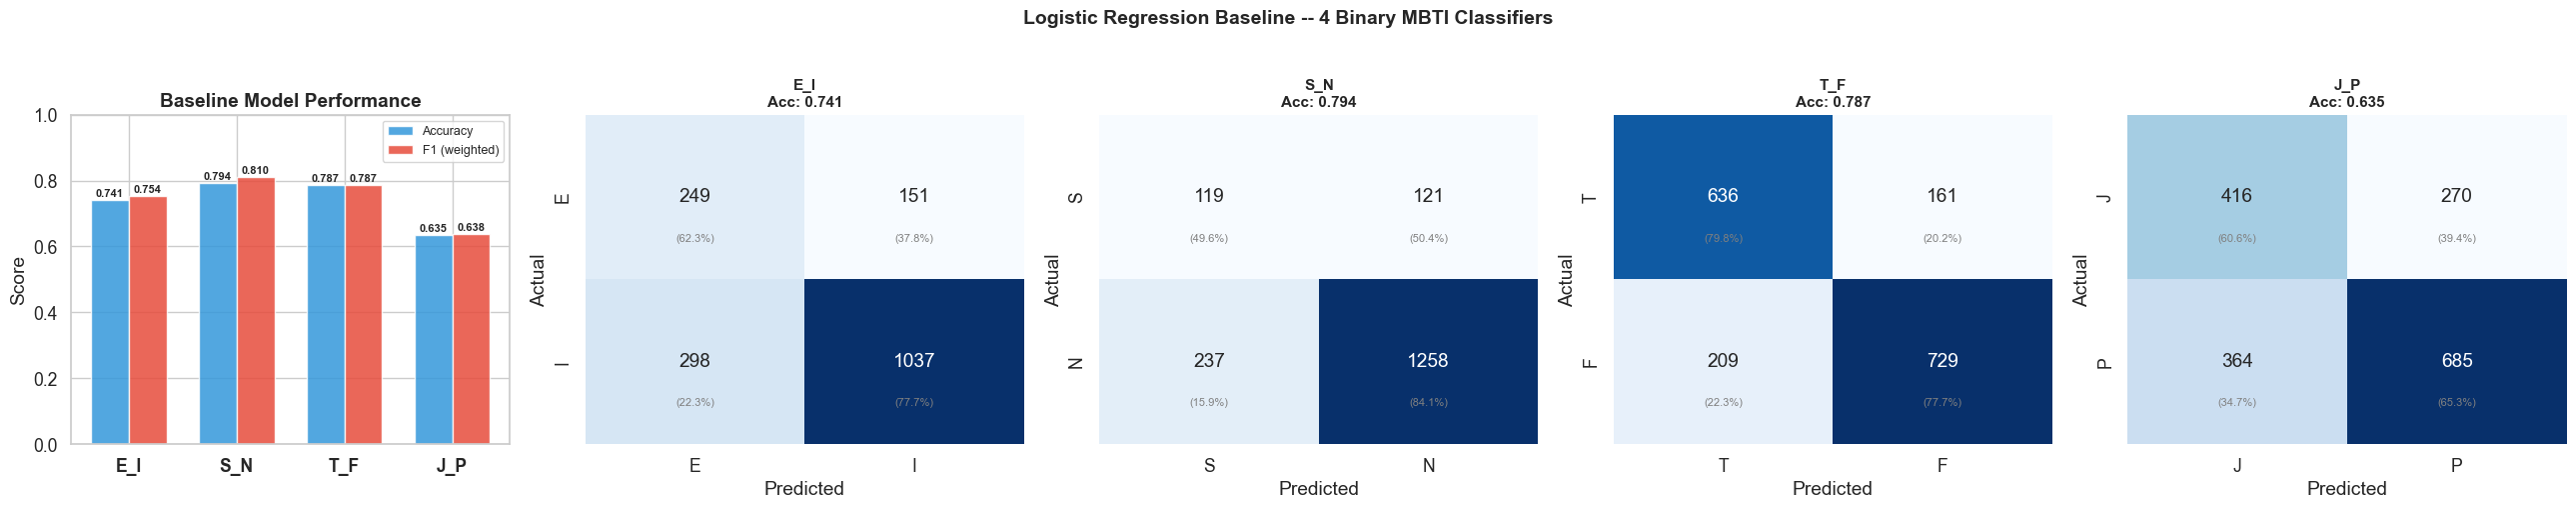


  Chart saved: phase3_baseline_results.png

[DONE]  Phase 3 complete -- baseline models trained and evaluated.
    Next -> Phase 4: Advanced Models & Hyperparameter Tuning



In [9]:
df, models, tfidf, results = main()